# 3.6. Generalization
D2L의 Generalization장을 PyTorch 기준으로 정리함.

일반화란 모델이 학습 데이터뿐만 아니라 처음 보는 새로운 데이터에서도 잘 작동하는 능력을 말한다.
선형회귀 앞 장에서는 모델을 학습시키는 방법을 배웠다. 모델이 학습 데이터에 잘 맞았다고 해서 좋은 모델이라고 할 수 없다. 진짜 중요한건 학습에 사용하지 않은 새로운 데이터에서 예측이 잘 되는가 이다.

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [2]:
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt
from torch.distributions.multinomial import Multinomial
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.manual_seed(0)
random.seed(0)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. 외운 것 ≠ 배운 것

D2L에서는 예시를 들어준다.
첫 번째 학생은 과거 시험 문제의 정답을 모두 외웠다.
두 번째 학생은 암기력은 부족하지만 문제의 패턴을 이해했다.

만약 시험 문제가 과거 그대로 나오면 첫 번째 학생이 잘 볼 것이다.
새로운 문제가 나오면 두 번째 학생이 더 잘볼 것이다.

머신러닝에서도 같다고 한다.

학습 데이터를 외운 모델 = training data에는 강하다.
패턴을 배운 모델 = 새로운 data에도 강하다.

학습 loss가 낮다고 좋아하면 안된다. 모델이 진짜 패턴을 배웠다는 증거가 아니기 때문이다.

## 2. 일반화가 왜 중요한가?

우리가 모델을 만드는 이유는 이미 본 데이터를 맞추기 위함이 아니다.

예를 들어서  
어제 주가를 맞추는 모델은 의미가 없고, 내일 주가를 예측해야 의미가 있다.

이미 진단받은 환자를 맞추는 모델은 의미없고, 처음 보는 환자에게도 잘 작동해야 의미있다.

D2L은 머신러닝의 핵심 문제는 데이터를 단순히 외우는 것이 아니라 일반화 가능한 패턴을 찾는 것이라고 설명했다. 현실에서는 유한한 데이터만 가지고 모델을 학습하기 때문에 모델이 학습 데이터에만 맞고 실제 분포의 패턴은 못 배울 위험이 있다.

## 3. Training Error와 Generalization Error

### Training Error
모델이 학습 데이터에서 얼마나 틀리는가를 계산한 에러이다.
$$
R_emp = (1/n) * sum(loss)
$$

학습 데이터 n개에 대해 loss를 계산하고 평균을 낸 것이다.  D2L은 training error을 학습 데이터셋에서 계산되는 통계량으로 정의했다.

```py
train_loss = loss_fn(model(X_train), y_train)
```

### Generalization Error
모델이 앞으로 만날 모든 가능한 데이터에서 평균적으로 얼마나 틀리는가의 에러이다.

세상의 모든 데이터를 가지고 있지 않기 때문에 이 값은 정확하게 계산할 수 없다.

D2L에서는 실제 데이터 분포의 정확한 형태를 알 수 없고, 무한한 데이터를 샘플링할 수도 없어서 Generalization error를 정확히 계산할 수 없다고 설명했다. 그래서 실제로는 별도로 뺀 test set이나 validation set으로 일반화 성능을 추정한다고 한다.

```py
val_loss = loss_fn(model(X_val), y_val)
```

## 4. IID 가정

D2L은 일반적인 supervised learning에서 train data와 test data가 같은 분포에서 독립적으로 뽑혔다고 가정한다고 설명한다. 이것을 IID assumption이라고 한다. IID는 Independent and Identically Distributed의 약자라고 한다.

`Independent` = 데이터들이 서로 독립적이다
`Identically Distributed` = 같은 분포에서 뽑혔다

예를 들어서  
학습 데이터가 한국 대학생 키,몸무게인데, 테스트 데이터가 미국 초등학생의 키,몸무게라면 같은 분포라고 보기 어렵다. 이경우에 학습 데이터에서 배운 패턴이 테스트 데이터에도 적용된다고 기대하기 어렵다.

일반화는 학습 데이터와 테스트 데이터가 비슷한 곳에서 나온것을 전제로 한다.

이 전제가 깨지면 distribution shift문제가 된다. D2L에선 train distribution P(X, Y)와 test distribution Q(X, Y)가 다르면 일반화를 말하려면 추가 가정이 필요하다 한다.

## 5. Model Complexity

Model complexity는 모델이 얼마나 복잡한 패턴을 표현할 수 있는지를 말한다.

단순한 모델은 표현력이 낮다. 그래서 학습 데이터조차 잘 못 맞출 수 있다. 이걸 underfitting이라 한다.

복잡한 모델은 표현력이 높다. 그래서 학습 데이터를 잘 맞출 수 있다. 너무 복잡하면 데이터의 진짜 패턴뿐 아니라 noise도 외울 수 있다. 이걸 overfitting이라 한다.

D2L은 단순한 모델과 충분한 데이터가 있으면 training error와 generalization error가 가까워지는 경향이 있지만, 모델이 복잡하거나 데이터가 적으면 training error은 낮아지고 generalization gap은 커질 수 있다고 한다.

데이터 양에 비해 모델이 복잡하면 위험하다. 근데 데이터가 충분하면 복잡한 모델이 좋을 수 있다. 데이터가 부족한데 복잡한 모델을 쓰면 외우기 쉽다.

## 6. Underfitting과 Overfitting

Underfitting은 모델이 너무 단순해서 학습 데이터조차 못 맞히는 상태이다.  
`train loss 높음 validation loss 높음`  
D2L은 training error와 validation error가 둘 다 크고 둘 사이의 차이가 작다면, 모델이 너무 단순해서 패턴을 포착하지 못한 상황일 수 있다고 설명한다. 이것이 underfitting이다.

Overfitting은 모델이 학습 데이터에 너무 맞춰진 상태이다.

train loss 낮음
validation loss 높음

D2L은 training error가 validation error보다 훨씬 낮으면 심한 overfitting일 수 있다고 설명한다. 다만 deep learning에서는 train 성능이 validation 성능보다 훨씬 좋은 모델도 실제로는 강력할 수 있으므로, 핵심은 gap 자체보다 최종 generalization error를 낮추는 것이다.

## 7. Polynomial Curve Fitting

D2L은 overfitting과 model complexity를 설명하기 위해서 polynomial curve fitting 예시를 들었다. polynomial은 다항식이다.

예를 들어서 입력 feature가 x 하나일 때, 단순 선형회귀는 다음과 같다

$$
\hat{y} = w_0 + w_1x
$$

1차함수이다. 여기에 x의 제곱, 세제곱 같은 항을 feature로 추가하면 더 복잡하 곡선을 표현할 수 있다.

$$
\hat{y} = w_0 + w_1x + w_2x^2 + w_3x^3 + ... + w_dx^d
$$

D2L은 이렇게 표현했다.

$$
\hat{y} = \sum_{i=0}^{d} x^i w_i
$$

여기에서 중요한 건 polynomial regression도 결국 linear regression이라는 것이다. 모델은 여전히 weight들에 대해 선형이기 때문이다. 입력을 다음과 같이 바꾼다고 생각하면 된다.

```text
원래 입력 : x

바꾼 입력 : [1, x, x^2, x^3, ..., x^d]
```

이러면 예측식은 다시 행렬곱으로 쓸 수 있다.

$$
\hat{y} = Xw
$$

여기에서 X는 원래 x가 아닌 polynomial feature로 바뀐 X이다.

## 8. 다항식 차수와 모델 복잡도

polynomial degree d가 커질수록 모델은 복잡해진다.

d = 1이면 직선만 표현할 수 있고,

d = 2면 포물선을 표현할 수 있다.

d = 10이면 훨씬 구불구불한 곡선을 표현할 수 있다.

복잡한 모델은 학습 데이터에 더 잘 맞을 수 있다. 그런데 너무 복잡해버리면 데이터의 진짜 패턴뿐 아니라 noise까지 외울 수 있다.

D2L의 핵심은
모델이 복잡해질수록 training loss는 보통 낮아진다.
그런데 validation loss가 항상 낮아지는건 아니다.

학습 데이터를 잘 맞치는 능력이랑 새로운 데이터에 잘 맞는 능력은 다른다.

D2L은 polynomial degree가 커지면 더 복잡한 함수를 표현할 수 있고, 고정된 학습 데이터에서는 높은 차수의 다항식이 낮은 차수보다 training error를 더 낮출 수 있다고 설명한다. 극단적으로는 데이터마다 서로 다른 x값이 있다면 충분히 높은 차수의 다항식이 학습 데이터를 완벽히 맞출 수도 있다.

## 9. Polynomial Regression 실험

직접 데이터를 만들어서 확인해보자

목표는 이것이다.
1. 너무 단순한 모델은 train loss와 validation loss가 모두 높다.
2. 적당한 복잡도의 모델은 train loss와 validation loss가 모두 낮다.
3. 너무 복잡한 모델은 train loss는 낮지만 validation loss가 높아질 수 있다.

torch.Size([30, 1]) torch.Size([30, 1])
torch.Size([100, 1]) torch.Size([100, 1])


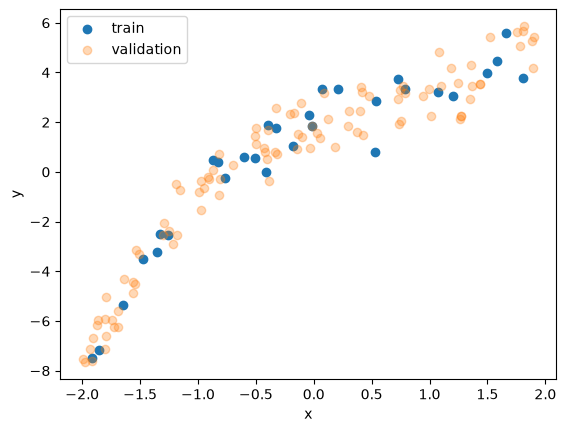

In [4]:
torch.manual_seed(0)

def make_data(n):
    X = torch.rand(n, 1) * 4 - 2  # -2 ~ 2 사이의 값
    noise = torch.randn(n, 1) * 0.8
    
    # 실제 정답 패턴은 3차 함수라고 가정
    y = 2 + 1.5 * X - 0.8 * X**2 + 0.5 * X**3 + noise
    return X, y

X_train, y_train = make_data(30)
X_val, y_val = make_data(100)

# X_train = 학습용 입력, y_train = 학습용 정답
# X_val = 검증용 입력, y_val = 검증용 정답
# 학습 데이터는 일부로 30개로 했다. 데이터가 적으면 overfitting이 더 잘 보인다.

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

plt.scatter(X_train, y_train, label="train")
plt.scatter(X_val, y_val, alpha=0.3, label="validation")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 10. Polynomial Feature 만들기

선형 모델은 이런 형태이다

$$
\hat{y} = Xw + b
$$

그런데 polynomial regression에서는 입력 X를 이렇게 바꾼다.
```text
x = 2
degree = 3

polynomial feature = [1, 2, 4, 8] ([x^0, x^1, x^2, x^3])
```

x^0은 항상 0이다. 이게 bias 역할을 한다.

In [ ]:
def poly_features(X, degree):
    features = []
    
    for i in range(degree + 1):
        features.append(X ** i)
    
    return torch.cat(features, dim=1)

example = torch.tensor([[2.0]])
print(poly_features(example, degree=3)) # 

tensor([[1., 2., 4., 8.]])


## 11. 여러 degree에 대해 학습해보기

여기선 gradient descent 대신 closed-form solution을 사용한다.
선형회귀는 다음 식으로 최적해를 구할 수 있다.

$$
w = (X^TX)^{-1}X^Ty
$$

근데 직접 inverse를 계산하는 건 수치적으로 불안정할 수 있다. 그래서 PyTorch의 `torch.linalg.lstsq`를 사용한다.

지금은 optimizer가 아니고 model complexity랑 generalization을 보는거라 closed-form으로 빠르게 비교하는 것이다.

degree= 1 | train_loss=2.1155 | val_loss=2.0834
degree= 2 | train_loss=0.7020 | val_loss=0.9155
degree= 3 | train_loss=0.4593 | val_loss=0.5644
degree= 5 | train_loss=0.4527 | val_loss=0.5915
degree=10 | train_loss=0.3487 | val_loss=2.2172
degree=20 | train_loss=0.4759 | val_loss=43.3477


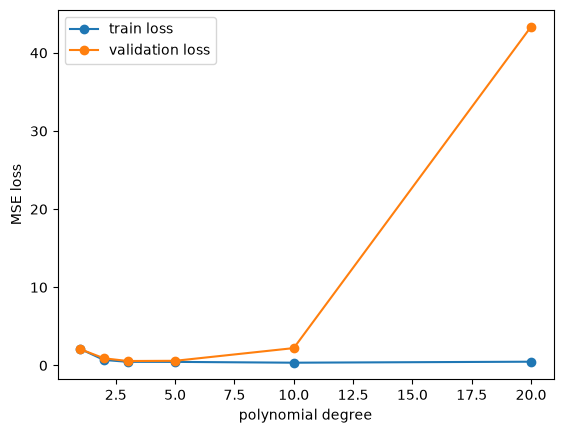

In [8]:
def fit_linear_closed_form(Phi, y):
    solution = torch.linalg.lstsq(Phi, y).solution
    return solution

def mse(y_hat, y):
    return ((y_hat - y) ** 2).mean().item()

degrees = [1, 2, 3, 5, 10, 20]
train_losses = []
val_losses = []

for degree in degrees:
    Phi_train = poly_features(X_train, degree)
    Phi_val = poly_features(X_val, degree)
    
    w = fit_linear_closed_form(Phi_train, y_train)
    
    y_train_hat = Phi_train @ w
    y_val_hat = Phi_val @ w
    
    train_loss = mse(y_train_hat, y_train)
    val_loss = mse(y_val_hat, y_val)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"degree={degree:2d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

plt.plot(degrees, train_losses, marker="o", label="train loss")
plt.plot(degrees, val_losses, marker="o", label="validation loss")
plt.xlabel("polynomial degree")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

degree가 커질수록 train_loss는 내려가기 쉽다. 그런데 val_loss는 다시 커질 수 있다.

모델은 학습 데이터를 더 잘 외우지만, 새로운 데이터에는 약해진 것이다.

- degree가 너무 낮으면 underfitting이다.
- degree가 적당하면 train loss와 validation loss가 모두 낮다.
- degree가 너무 높으면 train loss는 낮지만 validation loss가 커질 수 있다.